In [1]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()

In [4]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [14]:
iris.data[0:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [21]:
df=pd.concat([pd.DataFrame(iris.data),pd.Series(iris.target)],axis=1)
df.columns=iris.feature_names+['Target']
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [23]:
df['flower_name']=df['Target'].apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [28]:
#Data visualisation
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [29]:
df0=df[df.Target==0]
df1=df[df.Target==1]
df2=df[df.Target==2]

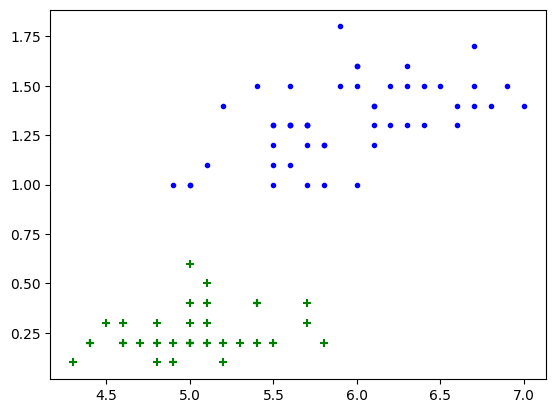

In [31]:
plt.scatter(df0['sepal length (cm)'],df0['petal width (cm)'],color='green',marker='+')
plt.scatter(df1['sepal length (cm)'],df1['petal width (cm)'],color='blue',marker='.')

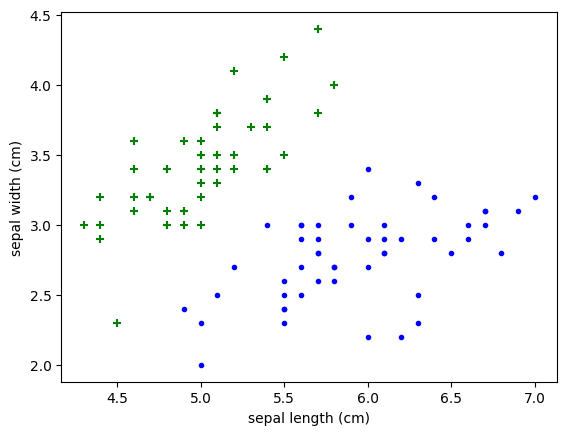

In [34]:
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.scatter(df0['sepal length (cm)'],df0['sepal width (cm)'],color='green',marker='+')
plt.scatter(df1['sepal length (cm)'],df1['sepal width (cm)'],color='blue',marker='.')

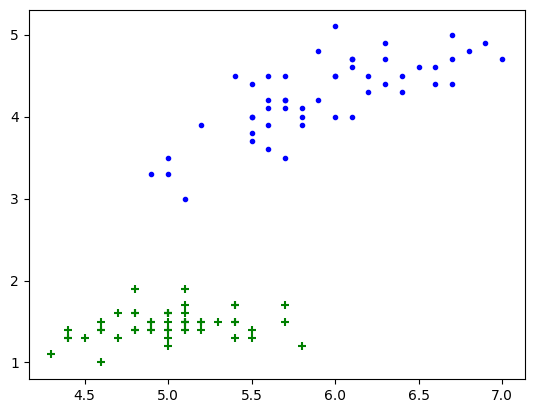

In [33]:
plt.scatter(df0['sepal length (cm)'],df0['petal length (cm)'],color='green',marker='+')
plt.scatter(df1['sepal length (cm)'],df1['petal length (cm)'],color='blue',marker='.')

## There is a clear classification among features so we can easily draw our boundary

In [15]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['Target','flower_name'])
y=df.Target

NameError: name 'df' is not defined

In [57]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [58]:
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
126,6.2,2.8,4.8,1.8
23,5.1,3.3,1.7,0.5
64,5.6,2.9,3.6,1.3
117,7.7,3.8,6.7,2.2
84,5.4,3.0,4.5,1.5
...,...,...,...,...
75,6.6,3.0,4.4,1.4
43,5.0,3.5,1.6,0.6
22,4.6,3.6,1.0,0.2
72,6.3,2.5,4.9,1.5


In [19]:
from sklearn.svm import SVC
model = SVC(C=1,kernel='linear')

In [60]:
model.fit(X_train,y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [61]:
model.score(X_test,y_test)

1.0

In [62]:
y_pred=model.predict(X_test)

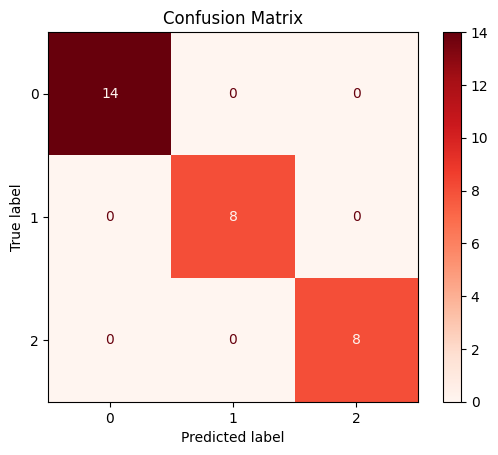

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title('Confusion Matrix')
plt.show()

## ASS

In [2]:
df_churn=pd.read_csv('Datasets/churn-bigml-20.csv')
df_churn.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [3]:
df_churn['International plan']=df_churn['International plan'].apply(lambda x:1 if x=='Yes'
                                                              else 0)
df_churn['Voice mail plan']=df_churn['Voice mail plan'].apply(lambda x:1 if x=='Yes'
                                                              else 0)

In [4]:
from sklearn.feature_selection import SelectKBest, chi2
dummies=pd.get_dummies(df_churn.State,dtype=int)
dummies.head()
df_churn2=pd.concat([df_churn,dummies],axis=1)
df_churn2.drop(columns=['State','LA'],inplace=True)

In [5]:
X=df_churn2.drop('Churn',axis=1)
y=df_churn2['Churn']

In [6]:
chi2_selector = SelectKBest(score_func=chi2, k=5)
X_kbest = chi2_selector.fit_transform(X, y)

In [7]:
selected_features = X.columns[chi2_selector.get_support()]
selected_features

Index(['Number vmail messages', 'Total day minutes', 'Total day charge',
       'Total eve minutes', 'Customer service calls'],
      dtype='object')

In [8]:
df_churn3=df_churn2[selected_features]

In [9]:
df_churn3=pd.concat([df_churn3,y],axis=1)
df_churn3.head()

,Number vmail messages,Total day minutes,Total day charge,Total eve minutes,Customer service calls,Churn
0,0,184.5,31.37,351.6,1,False
1,0,129.1,21.95,228.5,4,True
2,0,332.9,56.59,317.8,4,True
3,0,110.4,18.77,137.3,2,False
4,0,119.3,20.28,215.1,1,False


In [10]:
df_churn3['Churn']=df_churn3.apply(lambda x: 0 if x['Churn']==False 
                                  else 1,axis=1)
df_churn3.head()

,Number vmail messages,Total day minutes,Total day charge,Total eve minutes,Customer service calls,Churn
0,0,184.5,31.37,351.6,1,0
1,0,129.1,21.95,228.5,4,1
2,0,332.9,56.59,317.8,4,1
3,0,110.4,18.77,137.3,2,0
4,0,119.3,20.28,215.1,1,0


In [11]:
df0=df_churn3[df_churn3.Churn==0]
df1=df_churn3[df_churn3.Churn==1]

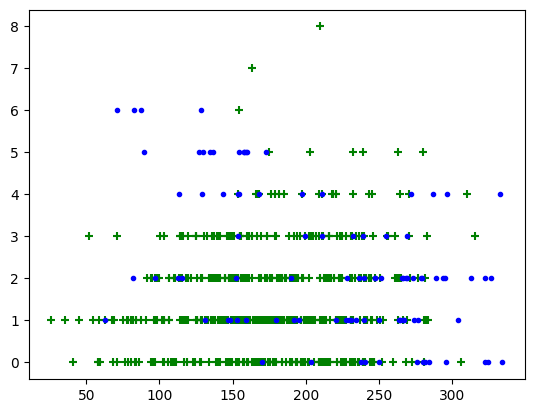

In [13]:
from matplotlib import pyplot as plt
plt.scatter(df0['Total day minutes'],df0['Customer service calls'],marker='+',color='green')
plt.scatter(df1['Total day minutes'],df1['Customer service calls'],marker='.',color='blue')

In [86]:
x=df_churn3.drop('Churn',axis=1)
y=df_churn3.Churn
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=30)

In [64]:
model2=SVC(C=1000,kernel='rbf')
model2.fit(X_train,y_train)

,C,1000
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [65]:
model2.score(X_test,y_test)

0.8955223880597015

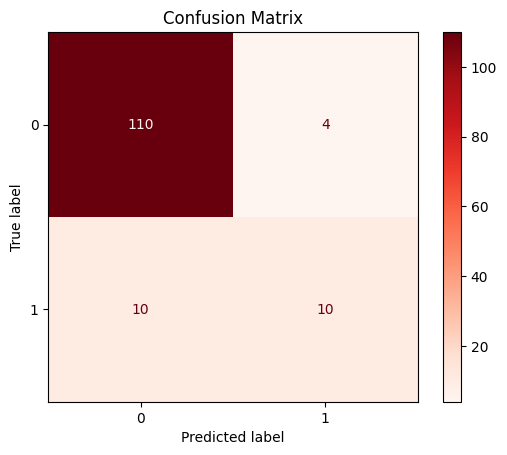

In [66]:
y_pred=model2.predict(X_test)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title('Confusion Matrix')
plt.show()

In [68]:
import joblib
joblib.dump(model2,'ChURN_SVM.pkl')

['ChURN_SVM.pkl']

In [69]:
from sklearn import tree

In [87]:
model3=tree.DecisionTreeClassifier()

In [88]:
model3.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [89]:
model3.score(X_test,y_test)

0.8805970149253731

In [90]:
y_pred2=model3.predict(X_test)

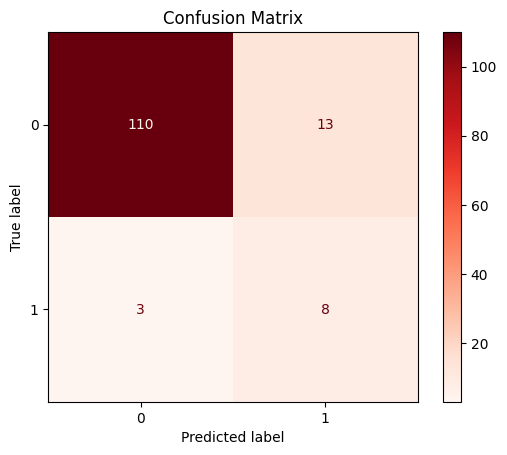

In [91]:
cm = confusion_matrix(y_test, y_pred2)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title('Confusion Matrix')
plt.show()